# <img src="./assets/course-icon.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

#### <a href="https://taldatech.github.io">Tal Daniel</a>

## Tutorial 06 - Convolutional Neural Networks & Visual Tasks
---
<center><img src="./assets/tut_conv_cnn.png" style="height:200px"></center>

<a href="https://mc.ai/how-does-convolutional-neural-network-work/">Image Source</a>

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---

* [2D Convolution](#-2D-Convolution)
* [Convolution-based Classification](#-Convolutuion-as-Feature-Extractors-for-Classification)
* [Multi-class Classification](#-Training-Multi-class-Classification-Models)
* [Convolutional Neural Networks (CNNs)](#-Convolutional-Neural-Networks-(CNNs))
* [Regularization](#-Regularization---Preventing-Overfitting)
* [Data Augmentation](#-Data-Augmentation)
* [CIFAR-10 Classification with PyTorch](#-Building-a-CNN-Classifier-for-CIFAR-10-with-PyTorch)
* [Visualizing CNN Filters and Activations](#-Visualizing-CNN-Filters)
* [CNNs Applications in Computer Vision](#-CNNs-Applications-in-Computer-Vision)
* [The Problem with CNNs](#-Are-CNNs-the-Holy-Grail?-The-Problem-with-CNNs)
* [Recommended Videos](#-Recommended-Videos)
* [Credits](#-Credits)

In [1]:
# imports for the tutorial
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# pytorch
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

## <img src="https://img.icons8.com/dusk/64/000000/layers.png" style="height:50px;display:inline"> 2D Convolution
---

* Mathematically, 2D convolution is defined as: $$ f[n, m] * h[n,m] = \sum_{k=-\infty}^{\infty}\sum_{l=-\infty}^{\infty} f[k, l]\cdot h[n-k, m-l] $$

* Intuition: A moving filter across an image being studied. 

* This applies a linear function on neighborhoods of pixels

<center><img src="./assets/tut_xiv_filter.jpg" style="height:200px" /></center>

* In our course, we will treat 2D convolution as *cross-correlation*.

### Numerical Example
---

<center><img src="./assets/tut_conv_num_ex.PNG" style="height:200px"></center>

<center><img src="./assets/tut_conv_anim.gif" style="height:400px"></center>

<center><img src="./assets/convolution-animation-3x3-kernel.gif" style="height:400px"></center>


<!-- ## <img src="https://img.icons8.com/color/96/000000/tweezers.png" style="height:50px;display:inline"> Convolution as Feature Extractors for Classification
---

- Convolutions help extract meaningful patterns from images.
- For example, derivative filters highlight **edges**.

<center><img src="./assets/tut_conv_derv_filt.PNG" style="height:300px"></center>

- Let’s recall the general classification setup.
    - In typical classification, we assume each input is a **feature vector**.
    - A classifier (e.g., MLP) learns to map these features to labels.

- But in image classification, the input is a grid of **raw pixels**.
- Are raw pixels good features? Not really — they lack structure and context.
- We need to **extract better features** from the pixel data.

- This is where convolution comes in — it transforms raw pixels into **spatially aware** features.
- Unlike MLPs (which are fully connected), convolutions preserve **local structures**.
- They can detect parts like edges, tails, or paws — all useful for distinguishing classes like cats and dogs.

- Think of each filter as detecting a class-specific pattern.
- Strong filter response → higher confidence the pattern exists in the image.

<center><img src="./assets/tut_conv_image_class.jpg" style="height:150px"></center>
<a href="https://www.mathworks.com/solutions/deep-learning/convolutional-neural-network.html">Image Source</a>
 -->

## <img src="https://img.icons8.com/color/96/000000/tweezers.png" style="height:50px;display:inline"> Convolution as Feature Extractors for Classification
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* Convolution is useful since it helps us find intersting insights/features from images.
    * E.g. Derivative filter Detects **edges** (Useful in classical CV algorithms).

<center><img src="./assets/tut_conv_derv_filt.PNG" style="height:150px"></center>

* Recall the classification task:
    * Learn a function $ f: \mathcal{X} \to \mathcal{Y} $, where $ x \in \mathcal{X} $ is the input features and $ y \in \mathcal{Y} $ is the class
    * So far we assumed **meaningfull** features
* Example - classifying *cats* and *dogs*.
    * How do we tell the difference between cats and dogs?
    * One can look at the length of the tail, shape of the paws, pattern of the fur and etc...
    * Humans can usually tell these just by looking at the sample. But what do computers see?

<!-- 
* Imagine that we have a filter for each class, and that by applying this filter, we get a **probability** for the input image to be from this filter's class. <center><img src="./assets/tut_conv_image_class.jpg" style="height:150px"></center>
    * <a href="https://www.mathworks.com/solutions/deep-learning/convolutional-neural-network.html">Image Source</a>
 -->
<!-- * In classification tasks, we need *good features* to learn a function that maps from samples to labels. -->
* **Raw pixels** are usually not expressive enough features! That is because raw pixels do not capture the *spatial relationship* in the image.
* Extracting features from raw pixels can be done using a deep learning network (which is a complex, non-linear function of the input).
    * Using just linear layers (multi-layer Perceptron) might work for simple images (e.g. MNIST), but they have a lot of parameters!
    * Using convolution, we can capture **spatial structures** (e.g., pixels the shape a tail).

</div>

## <img src="https://img.icons8.com/flat_round/64/000000/presentation.png" style="height:50px;display:inline"> Training Multi-class Classification Models
---

- Given DNN — how do we train it to predict the correct class?
- The final layer outputs a vector of size = number of classes.
  - E.g., 10 classes → output vector of size 10.
- Each entry reflects the probability of a class.
- Raw outputs are **scores**, not probabilities.
- Apply **Softmax** to convert scores into probabilities.
    $$ Softmax(x_i) = \frac{e^{x_i}}{\sum_{j=1}^M e^{x_j}}, i \in [1,...,M], x \in \mathcal{R}^M  $$
    * This forces the output vector to sum to 1, just like probabilities.

<center><img src="./assets/tut_conv_softmax.PNG" style="height:150px"></center>

- At evaluation predict class using $argmax$:
  $$ \hat{y} = Softmax(NN(x)) $$ $$ c_{pred} = argmax_i (\hat{y})  $$

<!-- ## <img src="https://img.icons8.com/flat_round/64/000000/presentation.png" style="height:50px;display:inline"> Training Multi-class Classification Models
---
* Assume we designed an architecture for classification, but how do we train it to output the correct class of the input (for example, an image)? Just as we did previously!
* The output of the final fully-connected layer in a classification model is a vector of length $\text{num-classes}$, which is exactly the number of classes we have (for example, in MNIST or CIFAR-10, we have 10 classes, thus the output dimension is 10)!
* In the output vector, we want entry $i$ to be the probability of the input to be from class $i$.
* But how do we force this vector to output probability and not just some numbers?
* We consider the final output vector to represent *scores*, which we will normalize to be probabilities using the **Softmax** function. -->

<!-- ### <img src="https://img.icons8.com/dusk/64/000000/s.png" style="height:50px;display:inline"> The Softmax Function
---
* The Softmax function is defined as: $$ Softmax(x_i) = \frac{e^{x_i}}{\sum_{j=1}^M e^{x_j}}, i \in [1,...,M], x \in \mathcal{R}^M  $$
* This forces the output vector to sum to 1, just like probabilities.

<center><img src="./assets/tut_conv_softmax.PNG" style="height:150px"></center> -->

<!-- ### <img src="https://img.icons8.com/plasticine/100/000000/unicorn.png"  style="height:50px;display:inline"> Making Predictions
---
* OK great, we have an output vector of probabilities, so how do we predict the label of the input image?
* Simple! Just take the $argmax$: $$ \hat{y} = Softmax(NN(x)) $$ $$ c_{pred} = argmax_i (\hat{y})  $$ -->

### <img src="https://img.icons8.com/dusk/64/000000/bearish.png" style="height:50px;display:inline"> Loss Function - Cross Entropy 
---

- We train models by minimizing a **loss function**.
- Let model output (after softmax) be $\hat{y}$, and true label $y$.

<center><img src="./assets/tut_conv_x_y.PNG" style="height:150px"></center>

- Ideally: $$ argmax(\hat{y}) = argmax(y) $$
- We want a loss that pushes $\hat{y}$ closer to $y$.
- Since $y$ is **one-hot** and $\hat{y}$ represents probabilities, we use **Cross Entropy**:
  
$$
\mathcal{L} \left( \hat{y}, y \right) = -\sum_{i=1}^{M} y_i \log(\hat{y}_i)  
$$
$$ \Rightarrow \mathcal{L} = -\log (p_c), \quad p_c = \hat{y}_{c} $$

- $c$ is the correct class; $\hat{y}_c$ is its predicted probability.
- Examples:
  - $p_c = 0$: loss = $\infty$ (worst case)
  - $p_c = 0.1$: loss ≈ 2.3 (poor prediction)
  - $p_c = 0.9$: loss ≈ 0.1 (good prediction)
  - $p_c = 1$: loss = 0 (perfect prediction)
- **Higher loss → worse prediction**; we minimize this!


<!-- ### <img src="https://img.icons8.com/dusk/64/000000/bearish.png" style="height:50px;display:inline"> Loss Function - Cross Entropy 
---
* In order to train the model in an end-to-end fashion, we need to define a loss function which we can minimize using optimization techniques.
* Let us assume that our model output (after softmax) is $\hat{y}$ and the real label (the real class, given to us) is $y$.
    * <center><img src="./assets/tut_conv_x_y.PNG" style="height:150px"></center>
* **Insight**: $$ argmax(\hat{y}) = argmax(y) $$
* Ideally, this is what we would want from our model, so what loss function would drive $\hat{y}$ to be as close as possible to $y$?
* As $y$ is a *one-hot vector* and $\hat{y}$ represents probabilities, the **Cross Entropy** loss function fits right in! -->

<!-- * Let $W$ denote the weights of the CNN, and $W^{*}$ the optimal weights.
* In this case, the optimal weights are: $$ W^{*} \leftarrow argmin_{W} \left(-\sum_{x, y} 1 \cdot \log (p_c) \right) $$ $$ p_c = \hat{y}_{c} $$
* $c \in [1,...,M]$ is the correct class, $\hat{y}_{c}$ is the $c^{th}$ entry in the output vector $\hat{y}$.
* So the **Cross Entropy** loss function is: $$\mathcal{L} = -\log (p_c)$$ -->

<!-- Let's analyze this loss fucntion, which represents how bad we are currently doing:
$$ p_c = 0 \rightarrow \mathcal{L} = -\log (0) = \infty $$
$$ p_c = 0.1 \rightarrow \mathcal{L} = -\log (0.1) = 2.3 $$
$$ p_c = 0.9 \rightarrow \mathcal{L} = -\log (0.9) = 0.1 $$
$$ p_c = 1 \rightarrow \mathcal{L} = -\log (1) = 0 $$

**The larger the loss, the worse the prediction**. We want to minimize it! -->

## <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> Convolutional Neural Networks (CNNs)
---

- CNNs are deep networks built from stacked convolutional layers.
- Primarily used for images, also useful in other domains (e.g., NLP).
- Convolution: sliding filters move across input pixels/nodes.

<center><img src="./assets/tut_xiv_layer.jpg" style="height:300px" /></center>

- Diagram: blue and green lines show filter positions.
- Filter weights are learned during training.

<!-- ## <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> Convolutional Neural Networks (CNNs)
---

* Convolutional Neural Networks (CNNs) are deep neural networks that contain layers of stacked convolution layers or filters. 
* They are mainly used for image datasets, but are also useful for other areas (natural language processing for example).
* In the convolutional part of the CNN, we can imagine a moving filter sliding across all the available nodes / pixels in the input image. This operation can also be illustrated using standard neural network node diagrams:
* <center><img src="./assets/tut_xiv_layer.jpg" style="height:300px" /></center>
* The first position of the moving filter connections is illustrated by the blue connections, and the second is shown with the green lines. The weights of each of these connections are usually learned. -->

### <img src="https://img.icons8.com/external-bearicons-outline-color-bearicons/64/000000/external-Block-yes-or-no-bearicons-outline-color-bearicons.png" style="height:50px;display:inline"> The Basic Principles of CNNs
---
We will now cover the basic building blocks of Convolutional Neural Networks (CNNs) and the ideas the enable efficient learning on image data.

### Feature Mapping and Multiple Channels
---
* Convolution filter weights are held <ins>constant</ins> as they are applied over the input nodes.
    * They can be trained to select certain features from the input data. 
    * E.g. in images, recognize common geometrical objects such as lines, edges and other shapes which make up objects. 
* $ \rightarrow$ Convolution layers need **multiple filters** which are trained to detect different features
    * Specifically, filters need different initialization (like we've learned in MLP)
    <!-- * To learn different filters to detect various features, we need them to be **initialized differently**, as we learned in the previous tutorial -- intialization matters! -->
  <center><img src="./assets/tut_conv_cnn_feature_maps.png" style="height:300px"></center>


### Pooling
---
* A sliding window type technique (like convolutions)
* Instead of applying learned weights, it applies a fixed function 
    * Example: **max pooling**, applies the $max()$ function over the contents of the window.

<center><img src="./assets/tut_conv_pooling.jpeg" style="height:200px"></center>

<a href="https://medium.com/@duanenielsen/deep-learning-cage-match-max-pooling-vs-convolutions-e42581387cb9">Image Source </a>

* Other pooling operators:
<center><img src="./assets/tut_conv_other_pool.PNG" style="height:200px"></center>

There are two main benefits to pooling in CNN's:
1. Reduces computation (decreases the spatial dimensions)
2. Makes feature detection more robust to object orientation and scale changes.

* Pooling generalizes over lower level, more complex information. 
    * Imagine we have convolutional filters that learns to detect the digit “9” 
    * In order for the Convolutional Neural Network to learn to classify the appearance of “9” in the image correctly, it needs to “activate” whenever a “9” is found anywhere in the image, no matter what the size or orientation the digit is (except for when it looks like “6”, that is). 
    * Pooling can assist with this higher level, generalized feature selection.

### Strides and Down-sampling
---
* In the pooling diagram below, you will notice that the pooling window shifts to the right each time by 2 places. 
* This is called a **stride of 2**, which should be considered both in the $x$ and $y$ direction. 
    * In other words, the stride is actually specified as $[2, 2]$. 
* One important thing to notice is that, if during pooling the stride is greater than 1, then the output size will be reduced. 
* As can be observed below, the 5 x 5 input is reduced to a 3 x 3 output. 
* This is a good thing – it is called down-sampling, and it can potentially reduces the number of trainable parameters in the model in case the number of parameters in following layers is dependent in the input dimension (e.g., a linear layer).

<center><img src="./assets/tut_xiv_max_pool.jpg" style="height:200px" /></center>

* Images from adventuresinmachinelearning.com

### Padding
---
* In the pooling diagram above there is an extra column and row added to the 5 x 5 input – this makes the effective size of the pooling space equal to 6 x 6. 
* This is to ensure that the 2 x 2 pooling window can operate correctly with a stride of [2, 2] -- *padding*. 
* These nodes are basically dummy nodes – because the values of these dummy nodes is 0, they are basically invisible to the max pooling operation. 
* Padding will need to be considered when constructing our Convolutional Neural Network in PyTorch.
* Padding is also used to **retain** or **enlarge** the dimensions of the input. For example, a "same" type padding means the output 2D tensor will have the same 2D dimensions as the input tensor.
* While we usually pad with zeros, it is possible to pad with other values (e.g., reflection or cyclic padding).

### Calculating the Convolutional Layer Output Shape
---
We define the following parameters of a *convolutional layer*:
* $W_{in}$ - the width of the input
* $F$ - filter size
* $P$ - padding
* $S$ -stride

The output width:
$$W_{out} = \frac{W_{in} - F + 2P}{S} + 1$$

Consider the input images of size $28\times 28$, filter size of $5\times 5$, padding of 2 and a stride of 1, the output of the convolutional layers, just before the FC:
$$W_{1, out} = \frac{28 - 5 + 2*2}{1} + 1 = 28 \rightarrow MaxPooling(2x2) \rightarrow 28 / 2 = 14$$
$$W_{2, out} = \frac{14 - 5 + 2*2}{1} + 1 = 14 \rightarrow MaxPooling(2x2) \rightarrow 14 / 2 = 7$$
So the input to the FC layer is $7x7=49$ (because we have 7 for the width and 7 for the height).

<center><img src="./assets/tut_conv_op.png" style="height:300px"></center>

<a href="https://towardsdatascience.com/a-comprehensive-introduction-to-different-types-of-convolutions-in-deep-learning-669281e58215">Image Source</a>

<center><img src="./assets/conv_anim.gif" style="height:300px"></center>

Animation by <a href="https://medium.com/@nadeemhqazi/a-brief-introduction-to-convolution-neural-network-4821215aa591">Nadeem Qazi</a>.

### Non-Linear Activations
---
* The key change made to the Perceptron that brought upon the era of deep learning is the addition of **activation function** to the output of each neuron. 
* These allow the learning of non-linear functions. A neural network without an activation function is essentially just a linear regression model.

<center><img src="./assets/tut_conv_activation.PNG"></center>

<!-- ### The FC Layer
---
* The fully connected layer can be thought of as attaching a standard classifier onto the information-rich output of the network, to “interpret” the results and finally produce a classification result. 
    * That is, the output of the convolutional layers is the new "input features" for the classifier.
* In order to attach this fully connected layer to the network, the dimensions of the output of the Convolutional Neural Network needs to be *flattened*.
* **Note**: some networks (e.g., Fully-Convolutional Network, FCN) do not use FC layers at all!
    * For example, you can design the convolutional kernels such that the final output is a tensor of shape `[num_classes, 1, 1]` (`num_channels` channels, height of 1 and width of 1) and use that for classification. It also useful for networks that perform image segmentation or generation, where the output is pixels. -->

### <img src="https://img.icons8.com/color/96/000000/layers.png" style="height:50px;display:inline"> Low Level (Shallow) and High Level (Deep) Features
---
* It is quite common to observe the features (outputs of the convolutional filters) at different levels of the network.
* **Low Level** - also called shallow features (first layers), which include lines, corners and edges.
* **Mid Level** - the middle level features, usually object parts.
* **High Level** - also called deep features (final layers), which include whole objects (global).

<center><img src="./assets/tut_conv_low_high_level_feat.png" style="height:350px"></center>

<a href="https://medium.com/analytics-vidhya/the-world-through-the-eyes-of-cnn-5a52c034dbeb">Image Source</a>

### CNN vs. Fully Connected
---

- Fully connected (FC) networks need many layers for good image classification.
- Adding more layers introduces problems:
    - **Vanishing gradients** (solved partly by ReLU, residual connections).
    - **Too many parameters** → slower training, risk of overfitting.
- CNNs address parameter explosion by exploiting **local correlations** in images (inductive bias).
- CNN filters are small (e.g., 3x3, 5x5), reducing trainable parameters.

<!-- ### CNN vs. Fully Connected
---
* Fully connected networks with a few layers can only do so much – to get close to state-of-the-art results in image classification it is necessary to go deeper. 
    * In other words, lots more layers are required in the network. 
* However, by adding a lot of additional layers, we come across some problems. 
    * First, we can run into the vanishing gradient problem. However, this can be solved to an extent by using sensible activation functions, such as the ReLU family of activations or residual networks (skip-connections). 
    * Another issue for deep fully connected networks is that the number of trainable parameters in the model (i.e. the weights) can grow rapidly. 
        * This means that the training slows down or becomes practically impossible, and also exposes the model to overfitting. CNNs try to solve this second problem by **exploiting correlations between adjacent inputs in images** (*inductive bias* - the locality of pixels).
* Trainable parameters: as Convolutional kernels/filters are usually of smaller sizes such as 7x7, 5x5 and 3x3, it keeps the number of trainable parameters rather low comparing to FC networks.   -->

### <img src="https://img.icons8.com/officel/80/000000/rope.png" style="height:50px;display:inline"> Regularization - Preventing Overfitting
---
- **Overfitting**: Training error decreases, but validation error eventually increases.
- Goal: Models that **generalize well** to unseen data.
<!-- - Best approach: **Use more diverse training data**. -->
<!-- - If more data isn't possible, apply **regularization** techniques. -->
- Generally, adding more training data improves generalization
    - But not always possible (expensive, not available)
- **Regularization** (intuition): place constraints on the quantity and type of information your model can store.
    - If a network can only afford to memorize a small number of patterns, the optimization process will force it to focus on the most prominent patterns, which have a better chance of generalizing well.
    - Beware that over-regularization may lead to  **Underfitting** (model too simple)

### Regularization via Loss Constraints
---

- Reduces model complexity by limiting the parameters magnitude.
- Encourages learning **generalizable patterns**.
- Typically adds a constraint term to the loss:
  - Common: $L_1, L_2$ regularization.
  $$
  \text{Loss}_{L_2} = \text{Original Loss} + \lambda \|w\|^2
  $$
- Helps model avoid memorizing training data.

### Dropout Regularization
---
<!-- - Introduced by Srivastava et al. (2014). -->
- Randomly "drops" neurons during training with probability \(p\).
- Effectively trains multiple sub-networks simultaneously.
- Reduces neuron co-dependency, improves robustness.
- Active **only during training** (`model.train()`), turned off during evaluation (`model.eval()`).

<center><img src="./assets/tut_conv_dropout.png" style="height:200px"></center>

[Image Source](https://www.oreilly.com/library/view/tensorflow-for-deep/9781491980446/ch04.html)  
[Learn More](https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/)

<!-- ### <img src="https://img.icons8.com/officel/80/000000/rope.png" style="height:50px;display:inline"> Regularization - Preventing Overfitting
---
* A common phenomenon in machine learning is that even though the training error keeps decreasing (training loss keeps going down, training accrucay goes up), the validation/test error goes down but then at some point it starts going up! (which is bad...)
    * In deep learning, we often see **Deep Double Descent**, which deviates from the classical ML regime.
* This is called **overfitting**. Although it's often possible to achieve high accuracy on the training set, what we really want is to develop models that generalize well to a testing set (or data they haven't seen before).
* If you train for too long though, the model will start to overfit and learn patterns from the training data that don't generalize to the test data. 
    * We need to find a balance!
* To prevent overfitting, the best solution is to **use more complete training data**. The dataset should cover the full range of inputs that the model is expected to handle. Additional data may only be useful if it covers new and interesting cases.
* A model trained on more complete data will naturally **generalize better**. When that is no longer possible, the next best solution is to use techniques like **regularization**. 
* **Regularization** places constraints on the quantity and type of information your model can store. If a network can only afford to memorize a small number of patterns, the optimization process will force it to focus on the most prominent patterns, which have a better chance of generalizing well. -->

<!-- * The opposite of overfitting is **underfitting**. Underfitting occurs when there is still room for improvement on the test data. 
    * This can happen for a number of reasons: If the model is not powerful enough, is over-regularized, or has simply not been trained long enough. This means the network has not learned the relevant patterns in the training data.
* Connection to **deep double descent** - adding regularization can alleviate this phenomenon. -->

<!-- * Regularization usually comes in the form of placing constraints on the parameters, or in the case of neural networks, constraints on the weights of the layers.
* It introduces a cost term for bringing in more features with the objective function. Hence, it tries to drive the coefficients of many variables to zero leading to a reduced cost term.
    * Common regularizations are $L_2, L_1$ regularizations: $$ \text{New Loss}_{L_2} = \text{Original Loss} + \lambda \mid \mid w \mid \mid^2$$
* For deep neural networks (and CNNs) a common regularization technique is **Dropout**. -->

<!-- #### Dropout Regularization
----
* First presented in <a href="http://jmlr.org/papers/v15/srivastava14a.html">Dropout: A Simple Way to Prevent Neural Networks from Overfitting</a>, 2014.
* Dropout is a regularization method that **approximates training a large number of neural networks with different architectures in parallel**.
* During training, some number of layer outputs (i.e. neurons) are randomly ignored or “dropped out” with some probability $p$. This has the effect of making the layer look-like and be treated-like a layer with a different number of nodes and connectivity to the prior layer.
* Dropout has the effect of making the training process noisy, forcing nodes within a layer to probabilistically take on more or less responsibility for the inputs.
* Dropout is activated **only during training** (`model.train()`). At test time, it is turned off (`model.eval()`).

Read more - <a href="https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/">A Gentle Introduction to Dropout for Regularizing Deep Neural Networks</a> -->

<!-- <!-- <center><img src="./assets/tut_conv_dropout.png" style="height:250px"></center> -->

<!-- <a href="https://www.oreilly.com/library/view/tensorflow-for-deep/9781491980446/ch04.html">Image Source</a> -->

### <img src="https://img.icons8.com/dusk/64/000000/variation.png" style="height:50px;display:inline"> Data Augmentation
---
* Data augmentation is a common technique to improve results and avoid overfitting, helping the network generalize better.
* **How do we get more data when there is limited number of samples?** We can perform data augmentation.
* Data augmenetation enriches the dataset by adding variations of the original samples.
    * And as you know, deep learning flourishes when there is A LOT of data.

* Popular augmentation techniques:
    * **Flip** - Flip images horizontally and/or vertically.
    * **Rotation** - Rotate the images at certain degrees. This may change the size of the image, thus, cropping or padding is a common fix for that.
    * **Scaling** - The image can be scaled outward or inward. This may also change the size of the image, thus, resizing (also stretching) is often followed.
    * **Cropping** - Randomly sample a section from the original image. Then resize this section to the original image size. This is called Random Crop.
    * **Translation** - Move the image along the X or Y direction (or both). This forces the neural network to look everywhere.
    * **Noise** - Overfitting usually happens when the network tries to learn high frequency features (patterns that occur a lot) that may not be useful. Gaussian noise, which has zero mean, essentially has data points in all frequencies, effectively distorting the high frequency features. This also means that lower frequency components (usually, your intended data) are also distorted, but your neural network can learn to look past that. Adding just the right amount of noise can enhance the learning capability (e.g., add Salt and Pepper).
    
Read More - <a href="https://nanonets.com/blog/data-augmentation-how-to-use-deep-learning-when-you-have-limited-data-part-2/">Data Augmentation | How to use Deep Learning when you have Limited Data</a>

<center><img src="./assets/tut_conv_augment.png" style="height:300px"></center>

<a href="https://towardsdatascience.com/machinex-image-data-augmentation-using-keras-b459ef87cd22">Image Source</a>

### <img src="./assets/kornia_logo.svg" style="height:50px;display:inline"> Kornia: Differentiable GPU-Accelerated Augmentations
---
* <a href="https://kornia.github.io/">Kornia</a> is a differentiable library that allows classical computer vision to be integrated into deep learning models.
* It allows to perform data augmentations and to apply other image and geometry operations/transformations directly on the GPU and making it possible to backpropagate through these operations!
    * This is not possible with the augmentations implemented in `torchvision` and usually requires to send the image tensor back to the CPU.
* See <a href="https://kornia.github.io/tutorials/">Jupyter Notebook Tutorials using Kornia</a>.

<center><img src="./assets/tut_conv_kornia_2.gif" style="height:300px"></center>

<table class="docutils align-default" id="id1">
<caption><span class="caption-text">Here is a benchmark performed on <a class="reference external" href="https://colab.research.google.com/drive/1b-HpK4EsZR8uolztgH4roNBLaDwcMULx?usp=sharing">Google Colab</a>
K80 GPU with different libraries and batch sizes. This benchmark shows
strong GPU augmentation speed acceleration brought by Kornia data augmentations. The image size is fixed to 224x224 and the
unit is milliseconds (ms).</span></caption>
<colgroup>
<col style="width: 27%">
<col style="width: 15%">
<col style="width: 15%">
<col style="width: 15%">
<col style="width: 15%">
<col style="width: 15%">
</colgroup>
<thead>
<tr class="row-odd"><th class="head"><p>Libraries</p></th>
<th class="head"><p>TorchVision</p></th>
<th class="head"><p>Albumentations</p></th>
<th class="head" colspan="3"><p>Kornia (GPU)</p></th>
</tr>
<tr class="row-even"><th class="head"><p>Batch Size</p></th>
<th class="head"><p>1</p></th>
<th class="head"><p>1</p></th>
<th class="head"><p>1</p></th>
<th class="head"><p>32</p></th>
<th class="head"><p>128</p></th>
</tr>
</thead>
<tbody>
<tr class="row-odd"><td><p>RandomPerspective</p></td>
<td><p>4.88±1.82</p></td>
<td><p>4.68±3.60</p></td>
<td><p>4.74±2.84</p></td>
<td><p>0.37±2.67</p></td>
<td><p>0.20±27.00</p></td>
</tr>
<tr class="row-even"><td><p>ColorJiggle</p></td>
<td><p>4.40±2.88</p></td>
<td><p>3.58±3.66</p></td>
<td><p>4.14±3.85</p></td>
<td><p>0.90±24.68</p></td>
<td><p>0.83±12.96</p></td>
</tr>
<tr class="row-odd"><td><p>RandomAffine</p></td>
<td><p>3.12±5.80</p></td>
<td><p>2.43±7.11</p></td>
<td><p>3.01±7.80</p></td>
<td><p>0.30±4.39</p></td>
<td><p>0.18±6.30</p></td>
</tr>
<tr class="row-even"><td><p>RandomVerticalFlip</p></td>
<td><p>0.32±0.08</p></td>
<td><p>0.34±0.16</p></td>
<td><p>0.35±0.82</p></td>
<td><p>0.02±0.13</p></td>
<td><p>0.01±0.35</p></td>
</tr>
<tr class="row-odd"><td><p>RandomHorizontalFlip</p></td>
<td><p>0.32±0.08</p></td>
<td><p>0.34±0.18</p></td>
<td><p>0.31±0.59</p></td>
<td><p>0.01±0.26</p></td>
<td><p>0.01±0.37</p></td>
</tr>
<tr class="row-even"><td><p>RandomRotate</p></td>
<td><p>1.82±4.70</p></td>
<td><p>1.59±4.33</p></td>
<td><p>1.58±4.44</p></td>
<td><p>0.25±2.09</p></td>
<td><p>0.17±5.69</p></td>
</tr>
<tr class="row-odd"><td><p>RandomCrop</p></td>
<td><p>4.09±3.41</p></td>
<td><p>4.03±4.94</p></td>
<td><p>3.84±3.07</p></td>
<td><p>0.16±1.17</p></td>
<td><p>0.08±9.42</p></td>
</tr>
<tr class="row-even"><td><p>RandomErasing</p></td>
<td><p>2.31±1.47</p></td>
<td><p>1.89±1.08</p></td>
<td><p>2.32±3.31</p></td>
<td><p>0.44±2.82</p></td>
<td><p>0.57±9.74</p></td>
</tr>
<tr class="row-odd"><td><p>RandomGrayscale</p></td>
<td><p>0.41±0.18</p></td>
<td><p>0.43±0.60</p></td>
<td><p>0.45±1.20</p></td>
<td><p>0.03±0.11</p></td>
<td><p>0.03±7.10</p></td>
</tr>
<tr class="row-even"><td><p>RandomResizedCrop</p></td>
<td><p>4.23±2.86</p></td>
<td><p>3.80±3.61</p></td>
<td><p>4.07±2.67</p></td>
<td><p>0.23±5.27</p></td>
<td><p>0.13±8.04</p></td>
</tr>
<tr class="row-odd"><td><p>RandomCenterCrop</p></td>
<td><p>2.93±1.29</p></td>
<td><p>2.81±1.38</p></td>
<td><p>2.88±2.34</p></td>
<td><p>0.13±2.20</p></td>
<td><p>0.07±9.41</p></td>
</tr>
</tbody>
</table>

### <img src="https://img.icons8.com/dusk/64/null/downloads.png" style="height:50px;display:inline"> Torchvision Datasets
---
* Torchvision provides many built-in datasets in the `torchvision.datasets` module, as well as utility classes for building your own datasets.
* <a href="https://pytorch.org/vision/stable/datasets.html#datasets">Torchvision Datasets</a>
    * Examples: `torchvision.datasets.CelebA`, `torchvision.datasets.Flowers102`, `torchvision.datasets.ImageNet`.
* If you want to create a dataset with your own images you can use <a href="https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder">`torchvision.datasets.ImageFolder`</a> and <a href="https://pytorch.org/vision/stable/generated/torchvision.datasets.VisionDataset.html#torchvision.datasets.VisionDataset">`torchvision.datasets.VisionDataset`</a>, or you can implement the `Dataset` class yourself.

## <img src="https://img.icons8.com/clouds/100/000000/dog.png" style="height:50px;display:inline"> The CIFAR-10 Dataset
---

* The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
    * There is also CIFAR-100, with 100 classes.
* The classes are completely mutually exclusive. There is no overlap between automobiles and trucks. "Automobile" includes sedans, SUVs, things of that sort. "Truck" includes only big trucks. Neither includes pickup trucks.
* <a href="https://www.cs.toronto.edu/~kriz/cifar.html">Official Site</a>

<center><img src="./assets/tut_conv_cifar10.PNG" style="height:300px"></center>


In [2]:
# define pre-processing steps on the images
# also called "data augementation" (only done for the train set)
# to use 'kornia' instead of torchvision, see example after

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # input is PIL image
    transforms.RandomHorizontalFlip(), # input is PIL image, can also set the probability parameter 'p'
    transforms.ToTensor(),  # uint8 values in [0, 255] -> float tensor with values [0, 1] 
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # [mu, sigma] standartization, RGB values
    # notice the order: first image transformations on PIL, then ToTensor, then normalization.
])

# how are the standartization params (mu, sigma) calculated? 
# iterate over the entire train set to get the R, G, and B values of the all images, compute their mean and std

# Normalize the test set same as training set without augmentation
transform_test = transforms.Compose([
    transforms.ToTensor(),  # uint8 values in [0, 255] -> float tensor with values [0, 1] 
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # [mu, sigma] standartization, RGB values of the train data
])

# test-time augementations (TTA): for a more robust prediciton, we can apply N augs on each input and get N scores, take the average of the scores.

# load dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

trainset = torchvision.datasets.CIFAR10(
    root='./datasets', train=True, download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./datasets', train=False, download=True, transform=transform_test)

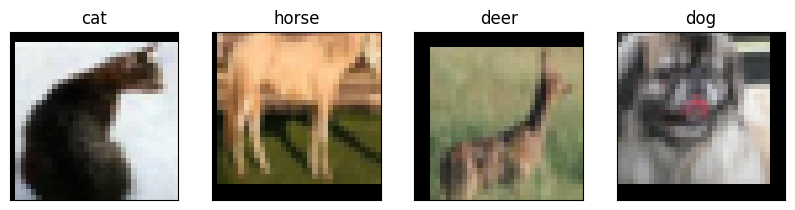

In [3]:
# let's see some of the images
def convert_to_imshow_format(image): 
    # first convert back to [0,1] range
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2023, 0.1994, 0.2010])
    image = image * std[:, None, None] + mean[:, None, None]  # [:, None, None] changes the shape from [N] to [N, 1, 1]
    image = image.clamp(0, 1).numpy()
    # convert from CHW to HWC
    # from 3x32x32 to 32x32x3
    return image.transpose(1, 2, 0)

trainloader = torch.utils.data.DataLoader(trainset, 
                                          batch_size=4,
                                          shuffle=True)
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, len(images), figsize=(10, 2.5))
for idx, image in enumerate(images):
    axes[idx].imshow(convert_to_imshow_format(image))
    axes[idx].set_title(classes[labels[idx]])
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

#### Image Augmentation with Kornia
---
Here is a code snippet of how we could perform image augmentations batch-wise to speed things up (and also make some of them differentiable).

* Note: image augmentations with Kornia are performed on the batch and are **not** part of `Dataset` and `DataLoader`.

In [4]:
from kornia import augmentation as K
from kornia.augmentation import AugmentationSequential

# when using 'kornia', no need to do augmentaions with `torch`, just:
transform_train_clean = transforms.ToTensor()

trainset_clean = torchvision.datasets.CIFAR10(
    root='./datasets', train=True, download=True, transform=transform_train_clean)

trainloader_clean = torch.utils.data.DataLoader(trainset_clean, 
                                          batch_size=4,
                                          shuffle=True)


# define a sequence of augmentations
aug_list = AugmentationSequential(
    K.ColorJitter(0.1, 0.1, 0.1, 0.1, p=1.0),
    K.RandomAffine(360, [0.1, 0.1], [0.7, 1.2], [30., 50.], p=1.0),
    K.RandomPerspective(0.5, p=1.0),
    same_on_batch=False,
)

batch_clean, labels = next(iter(trainloader_clean))
print(batch_clean.shape)

batch_aug = aug_list(batch_clean)  # [batch_size, num_ch, h, w]

torch.Size([4, 3, 32, 32])


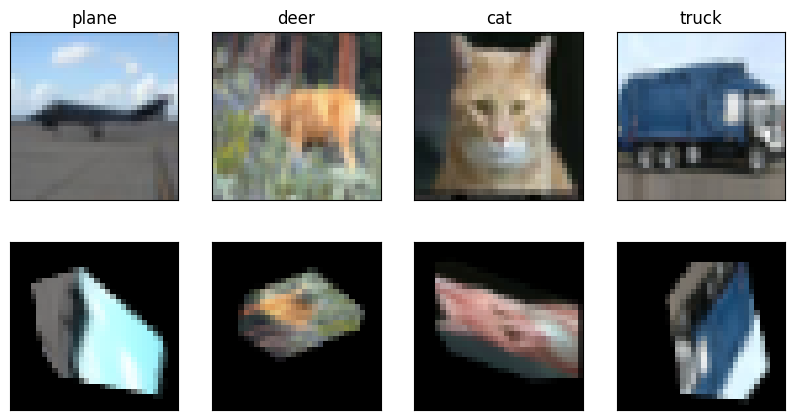

In [5]:
fig, axes = plt.subplots(2, len(batch_clean), figsize=(10, 5))
for idx in range(len(batch_clean)):
    # axes[0,idx].imshow(convert_to_imshow_format(batch_clean[idx]))
    axes[0,idx].imshow(batch_clean[idx].numpy().transpose(1, 2, 0))
    axes[0,idx].set_title(classes[labels[idx]])
    axes[0,idx].set_xticks([])
    axes[0,idx].set_yticks([])
    
    axes[1,idx].imshow(batch_aug[idx].numpy().transpose(1, 2, 0))
    axes[1,idx].set_xticks([])
    axes[1,idx].set_yticks([])

## <img src="https://img.icons8.com/bubbles/50/000000/fire-element.png" style="height:50px;display:inline"> Building a CNN-Classifier for CIFAR-10 with PyTorch
---

<center><img src="./assets/tut_conv_cifar_arch.PNG" style="height:300px"></center>

In [6]:
class CifarCNN(nn.Module):
    """CNN for the CIFAR-10 Datset"""

    def __init__(self):
        """CNN Builder."""
        super(CifarCNN, self).__init__()

        self.conv_layer = nn.Sequential(

            # Conv Layer block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            # `paading=1` is the same as `padding='same'` for 3x3 kernels size
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 2 = 32 / 2 = 16

            # Conv Layer block 2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 4 = 32 / 4 = 8
            nn.Dropout2d(p=0.05),

            # Conv Layer block 3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 8 = 32 / 8 = 4
            # the output dimensions: [batch_size, 256, h=input_resolution / 8, w=input_resolution / 8]
        )


        self.fc_layer = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(4096, 1024),  # 256 * 4 * 4 = 4096
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),
            nn.Linear(512, 10)
        )


    def forward(self, x):
        """Perform forward."""
        
        # conv layers
        x = self.conv_layer(x)  # [batch_size, channels=256, h_f=4, w_f=4]
        
        # flatten - can also use nn.Flatten() in __init__() instead
        x = x.view(x.size(0), -1)  # [batch_size, channels * h_f * w_f=4096]
        
        # fc layer
        x = self.fc_layer(x)  # [batch_size, n_classes=10]

        return x

### More Conv2D Properties
---
* <a href="https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html">`torch.nn.Conv2D`</a> has more hyperparameters you should know of.
* In detail: `torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)`
    * `dilation` controls the spacing between the kernel points, also known as the à trous algorithm ("atrous" convolution). This is usually used to upsample the input maps (e.g., for image segmentation and generation tasks, wher ethe output is an image). <a href="https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md">Visualization of `dilation`</a>.
    * `groups` controls the connections between inputs and outputs. `in_channels` and `out_channels` must both be divisible by groups. Examples:
        * At `groups=1` (default), all inputs are convolved to all outputs.
        * At `groups=in_channels`, each input channel is convolved with its own set of filters (of size $\frac{\text{out-channels}}{\text{in-channels}}$). When `groups == in_channels` and `out_channels == K * in_channels`, where $K$ is a positive integer, this operation is also known as a **“depthwise convolution”**.
    * `padding_mode` (from `torch` 1.1) controls the values of the padding, can be `'zeros', 'reflect', 'replicate' or 'circular'`. Default: `'zeros'`.
    * From `torch` 1.13, you can use strings to control the padding. `padding='valid'` is the same as no padding. `padding='same'` pads the input so the output has the shape as the input.
 
`same` convolution:
|kernel size| padding|
| ----       | ------ |
| 3 | 1 |
| 5 | 2 |
| 7 | 3 |

In [7]:
# how can we calcualte the output of the convolution automatically?
dummy_input = torch.zeros([1, 3, 32, 32])
dummy_model = CifarCNN()
dummy_output = dummy_model.conv_layer(dummy_input)
print(dummy_output.shape)
dummy_output = dummy_output.view(dummy_output.size(0), -1)
print(dummy_output.shape)
# how many weights (trainable parameters) we have in our model?
num_trainable_params = sum([p.numel() for p in dummy_model.parameters() if p.requires_grad])
print(f"num trainable weights: {num_trainable_params:,} ")

torch.Size([1, 256, 4, 4])
torch.Size([1, 4096])
num trainable weights: 5,852,170 


In [8]:
in_features = dummy_input[0].numel()
out_features = dummy_output[0].numel()
lin = nn.Linear(in_features, out_features)

print(lin)
print(f"Linear layer trainable weights: {lin.weight.numel():,}")

Linear(in_features=3072, out_features=4096, bias=True)
Linear layer trainable weights: 12,582,912


In [9]:
# calculate the model size on disk
num_trainable_params = sum([p.numel() for p in dummy_model.parameters() if p.requires_grad])
param_size = 0
for param in dummy_model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in dummy_model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024 ** 2
print(f"model size: {size_all_mb:.2f} MB")

model size: 22.33 MB


In [10]:
# time to train our model
# hyper-parameters
batch_size = 128
learning_rate = 1e-4
epochs = 20

# dataloaders - creating batches and shuffling the data
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2)

# device - cpu or gpu?
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# loss criterion
criterion = nn.CrossEntropyLoss()  # accepts 'logits' - unnormalized scores (no need to apply `softmax` manually)

# build our model and send it to the device
model = CifarCNN().to(device) # no need for parameters as we alredy defined them in the class

# optimizer - SGD, Adam, RMSProp...
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [11]:
# function to calcualte accuracy of the model
def calculate_accuracy(model, dataloader, device):
    model.eval() # put in evaluation mode,  turn off Dropout, BatchNorm uses learned statistics
    total_correct = 0
    total_images = 0
    confusion_matrix = np.zeros([10, 10], int)
    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_images += labels.size(0)
            total_correct += (predicted == labels).sum().item()
            for i, l in enumerate(labels):
                confusion_matrix[l.item(), predicted[i].item()] += 1 

    model_accuracy = total_correct / total_images * 100
    return model_accuracy, confusion_matrix

In [12]:
# training loop
for epoch in range(1, epochs + 1):
    model.train()  # put in training mode, turn on Dropout, BatchNorm uses batch's statistics
    running_loss = 0.0
    epoch_time = time.time()
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data
        # send them to device
        inputs = inputs.to(device)
        labels = labels.to(device)
        # augmentation with `kornia` happens here inputs = aug_list(inputs)

        # forward + backward + optimize
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, labels)  # calculate the loss
        # always the same 3 steps
        optimizer.zero_grad()  # zero the parameter gradients
        loss.backward()  # backpropagation
        optimizer.step()  # update parameters

        # print statistics
        running_loss += loss.data.item()

    # Normalizing the loss by the total number of train batches
    running_loss /= len(trainloader)

    # Calculate training/test set accuracy of the existing model
    train_accuracy, _ = calculate_accuracy(model, trainloader, device)
    test_accuracy, _ = calculate_accuracy(model, testloader, device)

    log = "Epoch: {} | Loss: {:.4f} | Training accuracy: {:.3f}% | Test accuracy: {:.3f}% | ".format(epoch, running_loss, train_accuracy, test_accuracy)
    # with f-strings
    # log = f"Epoch: {epoch} | Loss: {running_loss:.4f} | Training accuracy: {train_accuracy:.3f}% | Test accuracy: {test_accuracy:.3f}% |"
    epoch_time = time.time() - epoch_time
    log += "Epoch Time: {:.2f} secs".format(epoch_time)
    # with f-strings
    # log += f"Epoch Time: {epoch_time:.2f} secs"
    print(log)
    
    # save model
    if epoch % 20 == 0:
        print('==> Saving model ...')
        state = {
            'net': model.state_dict(),
            'epoch': epoch,
        }
        if not os.path.isdir('checkpoints'):
            os.mkdir('checkpoints')
        torch.save(state, './checkpoints/cifar_cnn_ckpt.pth')

print('==> Finished Training ...')

Epoch: 1 | Loss: 1.5275 | Training accuracy: 55.458% | Test accuracy: 57.440% | Epoch Time: 19.15 secs
Epoch: 2 | Loss: 1.1036 | Training accuracy: 59.762% | Test accuracy: 61.730% | Epoch Time: 18.93 secs
Epoch: 3 | Loss: 0.9277 | Training accuracy: 68.978% | Test accuracy: 69.250% | Epoch Time: 18.55 secs
Epoch: 4 | Loss: 0.8097 | Training accuracy: 71.636% | Test accuracy: 71.150% | Epoch Time: 19.03 secs
Epoch: 5 | Loss: 0.7274 | Training accuracy: 75.268% | Test accuracy: 74.900% | Epoch Time: 18.96 secs
Epoch: 6 | Loss: 0.6677 | Training accuracy: 78.938% | Test accuracy: 78.500% | Epoch Time: 19.12 secs
Epoch: 7 | Loss: 0.6173 | Training accuracy: 80.088% | Test accuracy: 78.620% | Epoch Time: 18.89 secs
Epoch: 8 | Loss: 0.5772 | Training accuracy: 81.232% | Test accuracy: 78.970% | Epoch Time: 18.92 secs
Epoch: 9 | Loss: 0.5402 | Training accuracy: 83.636% | Test accuracy: 81.390% | Epoch Time: 19.19 secs
Epoch: 10 | Loss: 0.5081 | Training accuracy: 84.940% | Test accuracy: 82

test accuracy: 85.340%


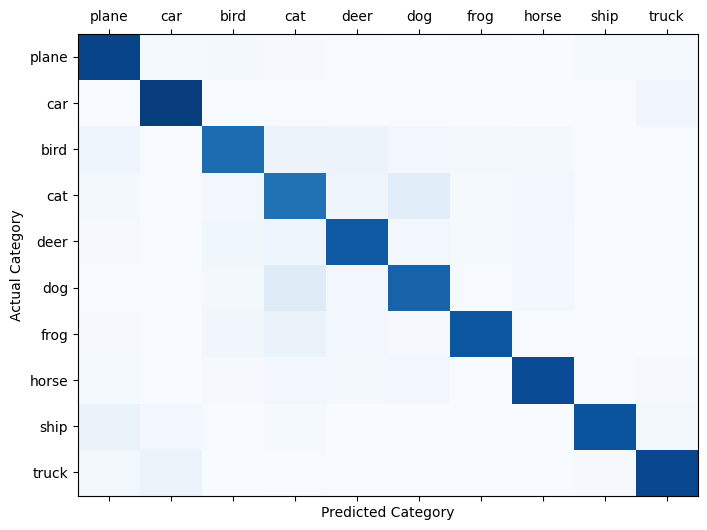

In [13]:
# load model, calculate accuracy and confusion matrix
model = CifarCNN().to(device)
state = torch.load('./checkpoints/cifar_cnn_ckpt.pth', map_location=device)
model.load_state_dict(state['net'])
# note: `map_location` is necessary if you trained on the GPU and want to run inference on the CPU

test_accuracy, confusion_matrix = calculate_accuracy(model, testloader, device)
print("test accuracy: {:.3f}%".format(test_accuracy))

# plot confusion matrix
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.matshow(confusion_matrix, aspect='auto', vmin=0, vmax=1000, cmap=plt.get_cmap('Blues'))
plt.ylabel('Actual Category')
plt.yticks(range(10), classes)
plt.xlabel('Predicted Category')
plt.xticks(range(10), classes)
plt.show()

## <img src="https://img.icons8.com/dusk/64/000000/doughnut-chart.png" style="height:50px;display:inline"> Visualizing CNN Filters
---

#### CNN Explainer Demo
---
<a href="https://poloclub.github.io/cnn-explainer/">Open Demo</a>

<center><img src="./assets/convlayer_demo.gif" style="height:200px"></center>

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Dropout2d(p=0.05, inplace=False)
  (13): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (14): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (15): ReLU(inplace=True)
  (16): Conv2d(2

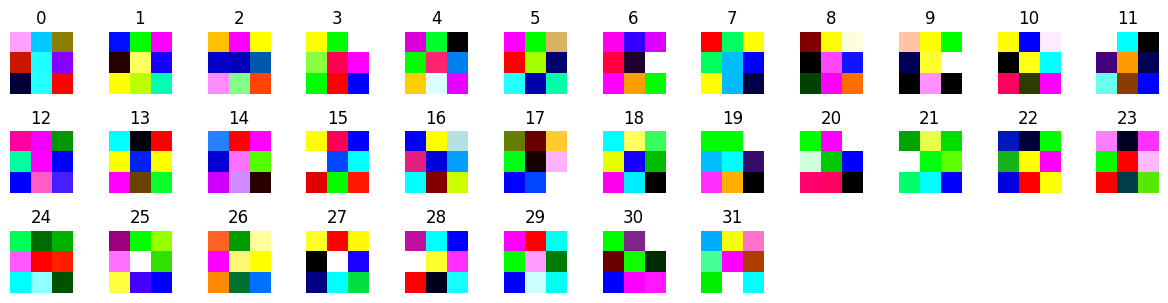

In [14]:
# visualize filters
# see available layers, in our case, the stacked layers are called "conv_layer"
print(model.conv_layer)
# extracting the model features at the particular layer number
layer = model.conv_layer[0]
# get the weights
weight_tensor = layer.weight.data.cpu()

# get the number of kernals
num_kernels = weight_tensor.shape[0]    

#define number of columns for subplots
num_cols = 12
# rows = num of kernels
num_rows = num_kernels

#set the figure size
fig = plt.figure(figsize=(num_cols, num_rows))

# looping through all the kernels
for i in range(weight_tensor.shape[0]):
    ax1 = fig.add_subplot(num_rows, num_cols, i+1)

    #for each kernel, we convert the tensor to numpy 
    npimg = np.array(weight_tensor[i].numpy(), np.float32)
    #standardize the numpy image
    npimg = (npimg - np.mean(npimg)) / np.std(npimg)
    npimg = np.minimum(1, np.maximum(0, (npimg + 0.5)))
    npimg = npimg.transpose((1, 2, 0))
    ax1.imshow(npimg)
    ax1.axis('off')
    ax1.set_title(str(i))
    ax1.set_xticklabels([])
    ax1.set_yticklabels([])

plt.tight_layout()

## <img src="https://img.icons8.com/color/96/000000/xray.png" style="height:50px;display:inline"> Visualizing Layer Output
---
* We can see which neurons are active for every input image.
* This way we can a better understanding of what the network sees during forward pass, which probably affects the final prediction.
* Let's see an example by <a href="https://github.com/sar-gupta/convisualize_nb/blob/master/cnn-visualize.ipynb">Sarthak Gupta </a>.

In [17]:
from PIL import Image 

# helper functions
def to_grayscale(image):
    """
    input is (d,w,h)
    converts 3D image tensor to grayscale images corresponding to each channel
    """
    image = torch.sum(image, dim=0)
    image = torch.div(image, image.shape[0])
    return image

def normalize(image, device=torch.device("cpu")):
    normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
    )
    preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
    ])
    image = preprocess(image).unsqueeze(0).to(device)
    return image


def predict(image, model, labels=None):
    _, index = model(image).data[0].max(0)
    if labels is not None:
        return str(index.item()), labels[str(index.item())][1]
    else:
        return str(index.item()) 
    
def deprocess(image, device=torch.device("cpu")):
    return image * torch.tensor([0.229, 0.224, 0.225]).to(device) + torch.tensor([0.485, 0.456, 0.406]).to(device)

def load_image(path):
    image = Image.open(path)
    plt.imshow(image)
    plt.title("Image loaded successfully")
    return image

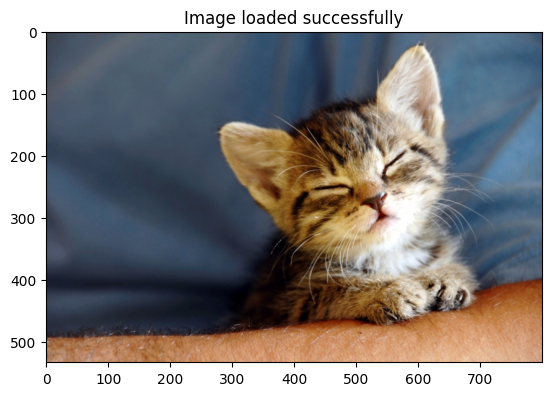

In [20]:
# load sample image
kitten_img = load_image("./assets/kitten.jpg")
img = load_image("./assets/kitten.jpg")


### <img src="https://img.icons8.com/nolan/64/download-from-cloud.png" style="height:50px;display:inline"> Torchvision Pre-Trained Models
---
* The `torchvision.models` subpackage contains definitions of models for addressing different tasks, including: image classification, pixelwise semantic segmentation, object detection, instance segmentation, person keypoint detection, video classification, and optical flow.
* You can see all the available here - <a href="https://pytorch.org/vision/stable/models.html">Models and pre-trained weights</a>.
    * In code, you can use <a href="https://pytorch.org/vision/stable/models.html#model-registration-mechanism">`torchvision.models.list_models`</a> to see a list of all available models.
* Examples:

In [21]:
# examples of laoding pre-trained models - not meant to run, check out the link in previous block.
from torchvision.models import resnet50, ResNet50_Weights

# Example 1
# Using pretrained weights:
resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
resnet50(weights="IMAGENET1K_V1")
resnet50(pretrained=True)  # old approach, deprecated

# Using no weights:
resnet50(weights=None)
resnet50()
resnet50(pretrained=False)  # old approach, deprecated

# Initialize the Weight Transforms
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

# Apply it to the input image
img_transformed = preprocess(img)

In [24]:
# Example 2
from torchvision.io import read_image
from torchvision.models import resnet50, ResNet50_Weights

# img = read_image("test/assets/encode_jpeg/grace_hopper_517x606.jpg")

# Step 1: Initialize model with the best available weights
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Step 4: Use the model and print the predicted category
prediction = model(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/hagaymi/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


tabby: 17.0%


In [25]:
# load pre-trained model
from torchvision.models import vgg16, VGG16_Weights
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).to(device)
model = vgg16(weights="DEFAULT").to(device)  # alternative
# model = vgg16(weights="IMAGENET1K_V1").to(device)  # another alternative
# model = vgg16(pretrained=True).to(device)  # old, deprecated
# we are not interested in training this network, so no need for gradient calculation
model.requires_grad_(False)
# put in evaluation mode to turn-off DropOut and use BatchNorm's running mean and std (not the batch mean and std)
model.eval();

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/hagaymi/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [26]:
# pre-process image and predict label
prep_img = normalize(kitten_img, device)
print("predicted class:", predict(prep_img, model))

predicted class: 281


#### Output of Each Layer
---

In [27]:
def layer_outputs(image, model):
    modulelist = list(model.features.modules())
    outputs = []
    names = []
    for layer in modulelist[1:]:
        image = layer(image)
        outputs.append(image)
        names.append(str(layer))
        
    output_im = []
    for i in outputs:
        i = i.squeeze(0)
        temp = to_grayscale(i)  # take the mean
        output_im.append(temp.data.cpu().numpy())
        
    fig = plt.figure(figsize=(30, 50))

    for i in range(len(output_im)):
        a = fig.add_subplot(8, 4, i+1)
        imgplot = plt.imshow(output_im[i])
        a.set_axis_off()
        a.set_title(names[i].partition('(')[0], fontsize=30)
    plt.tight_layout()
#     plt.savefig('layer_outputs.jpg', bbox_inches='tight')

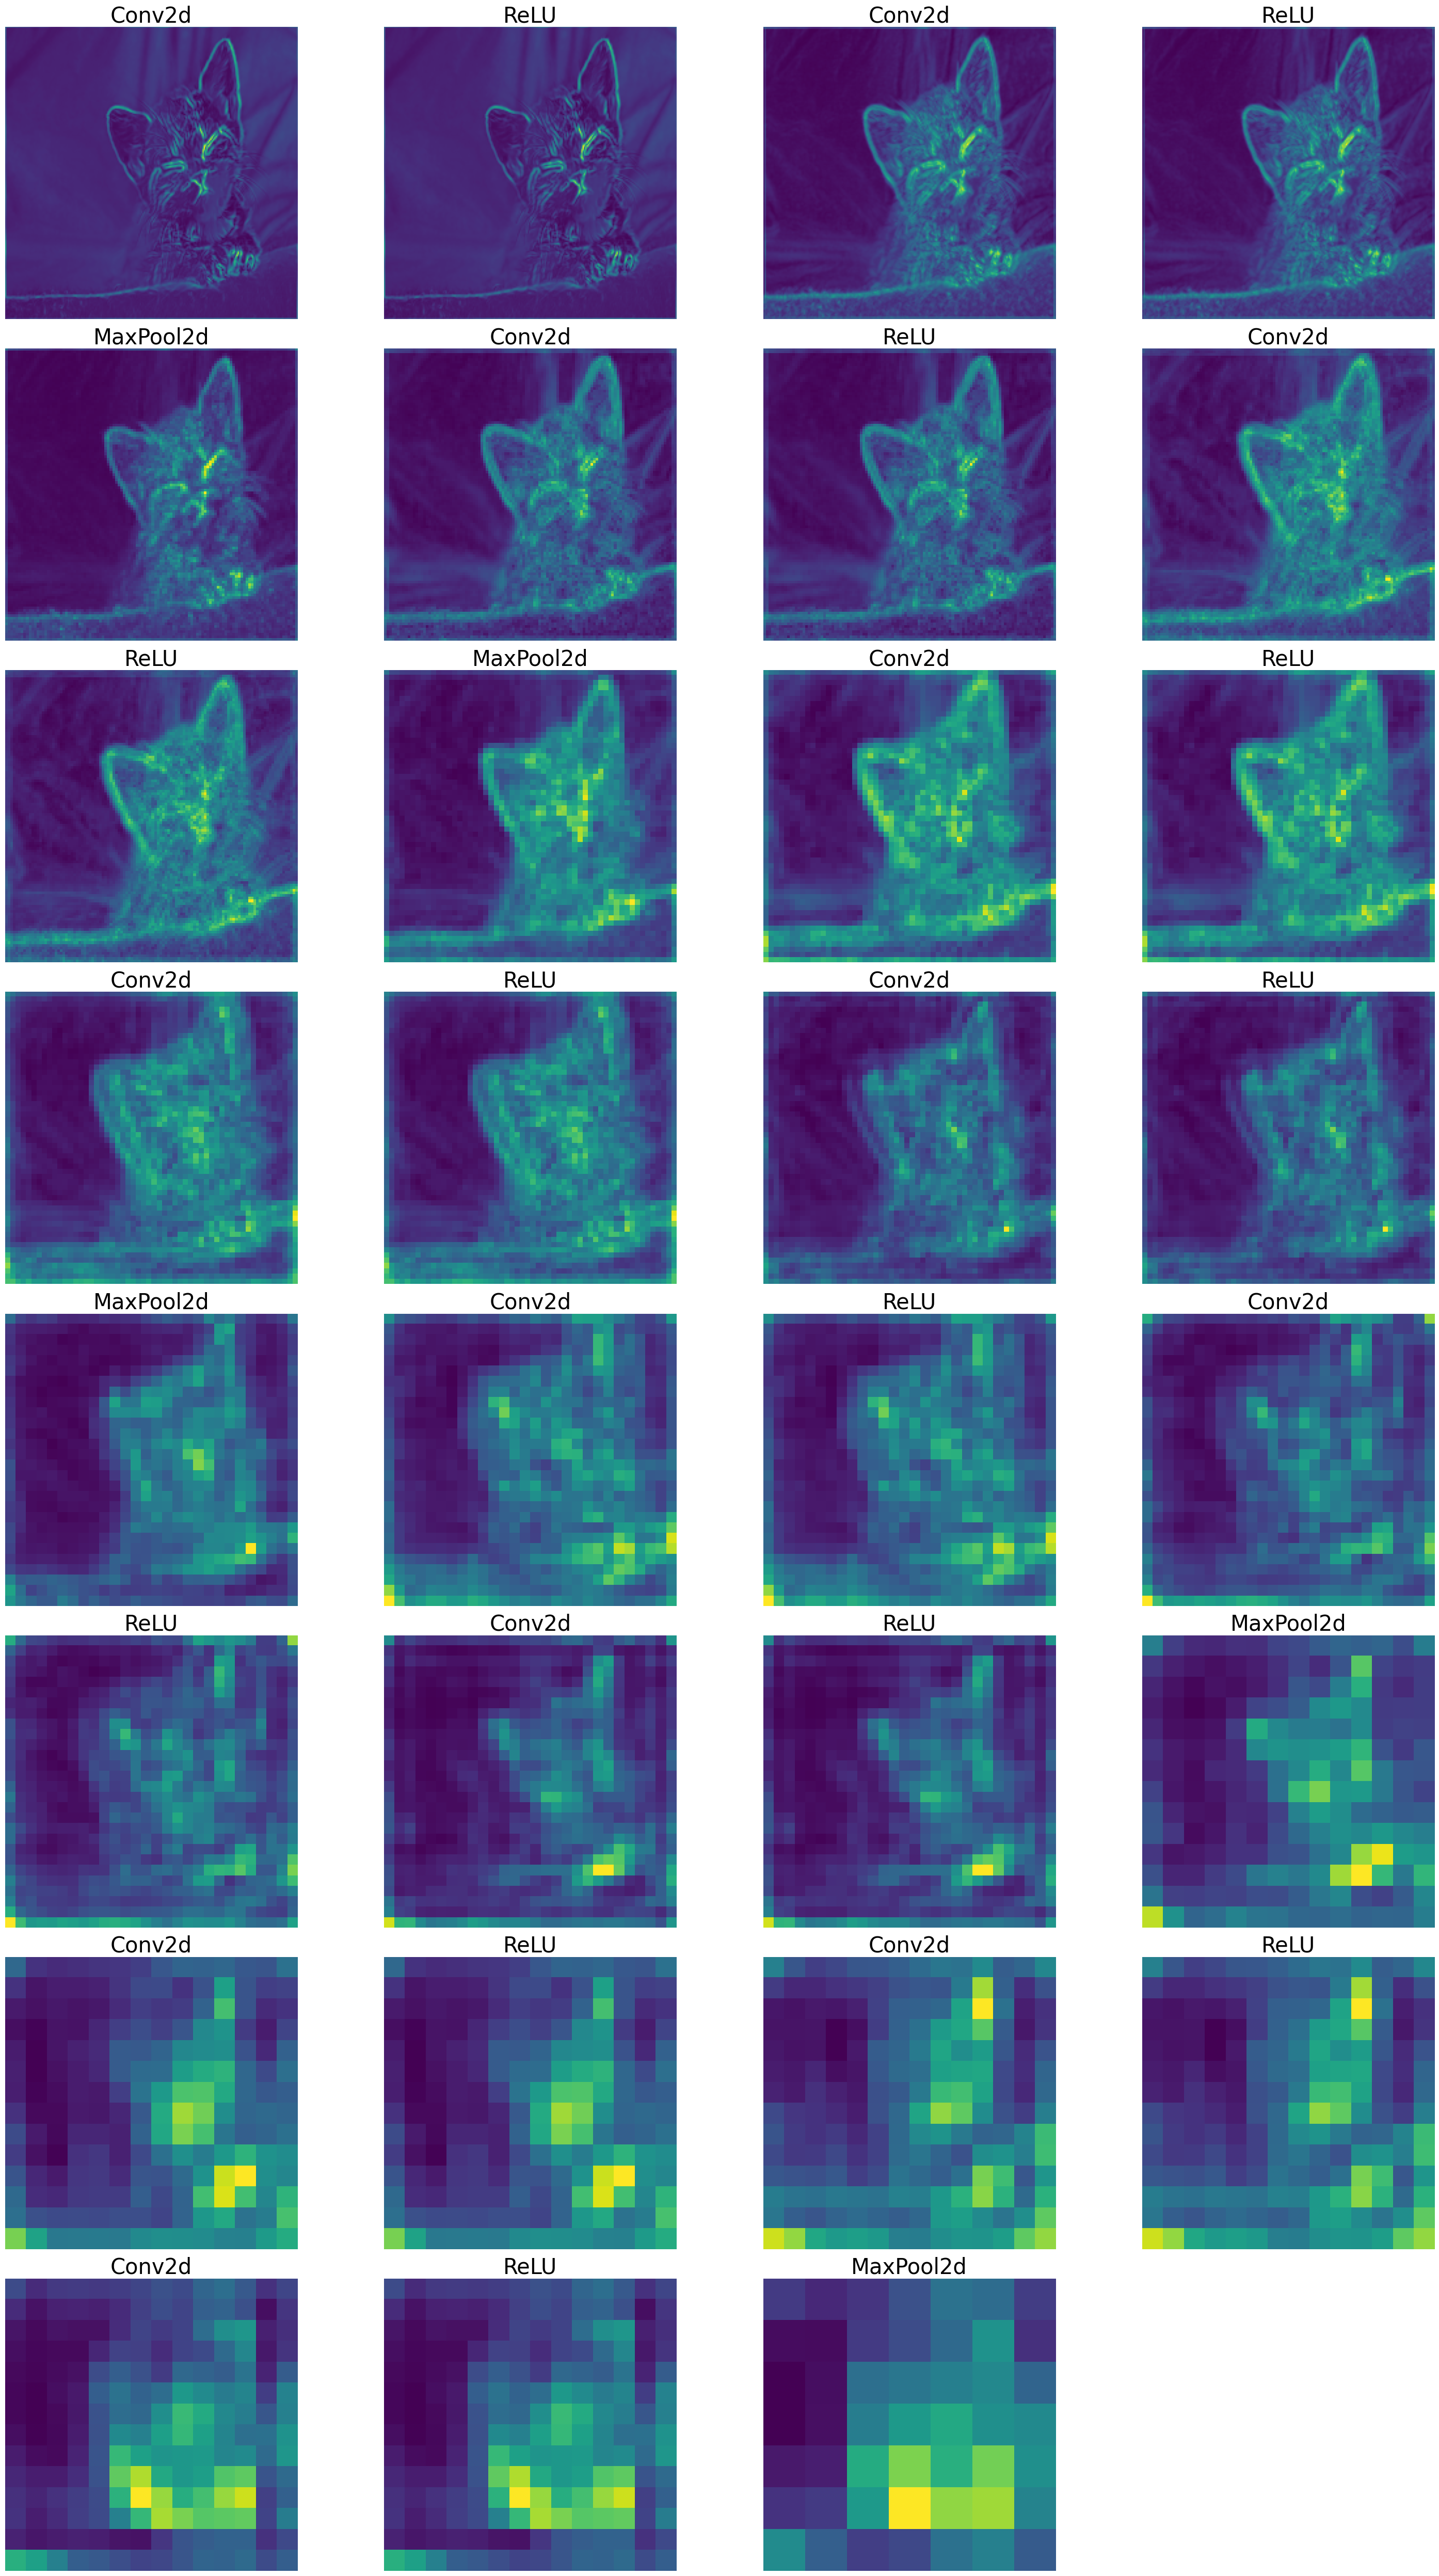

In [28]:
layer_outputs(prep_img, model)

#### Output of Each Filter for a Certain Layer
---

In [31]:
def filter_outputs(image, model, layer_to_visualize):
    modulelist = list(model.features.modules())
    if layer_to_visualize < 0:
        layer_to_visualize += 31
    output = None
    name = None
    for count, layer in enumerate(modulelist[1:]):
        image = layer(image)
        if count == layer_to_visualize: 
            output = image
            name = str(layer)
    
    filters = []
    output = output.data.squeeze().cpu().numpy()
    for i in range(output.shape[0]):
        filters.append(output[i,:,:])
        
    fig = plt.figure(figsize=(10, 10))

    for i in range(int(np.sqrt(len(filters))) * int(np.sqrt(len(filters)))):
        ax = fig.add_subplot(int(np.sqrt(len(filters))), int(np.sqrt(len(filters))), i+1)
        imgplot = ax.imshow(filters[i])
        ax.set_axis_off()
    plt.tight_layout()

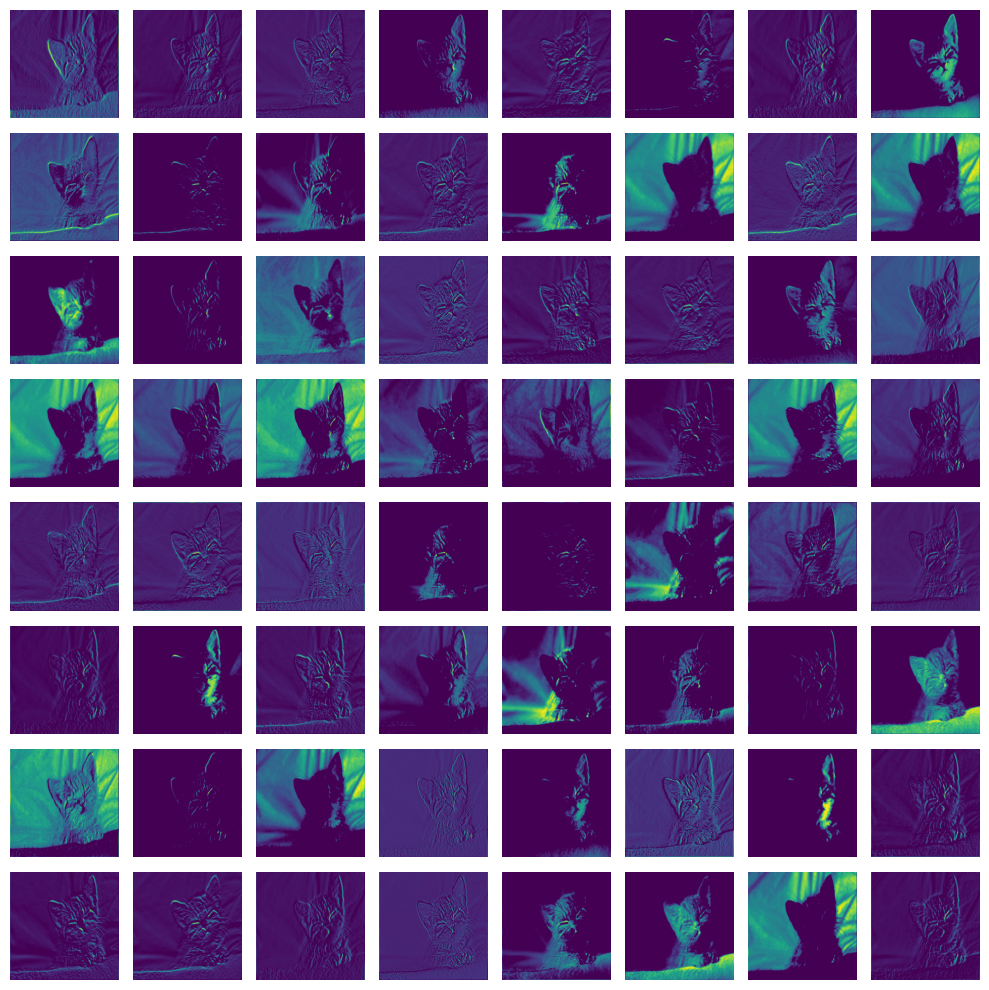

In [32]:
filter_outputs(prep_img, model, 0)

## <img src="https://img.icons8.com/cute-clipart/64/000000/easter-egg.png" style="height:50px;display:inline"> Are CNNs the Holy Grail? The Problem with CNNs
---
#### Deep NNs are sensitive to adversarial attacks.
---
* For example: consider the following image, where on the left, we have an image of a pig that is correctly classified by a state-of-the-art convolutional neural network. 
* After perturbing the image slightly (every pixel is in the range [0, 1] and changed by at most 0.005), the network now returns class “airliner” with high confidence.
    
<center><img src="./assets/tut_conv_pig.png" style="height:200px"></center>

<a href="http://gradientscience.org/intro_adversarial/">Image Source</a>

#### Recognition algorithms generalize poorly to new environments
---
<center><img src="./assets/tut_conv_cow.PNG" style="height:200px"></center>

<a href="https://arxiv.org/pdf/1807.04975.pdf">Recognition in Terra Incognita (Beery et al., 2018)</a>

#### Neural Networks tend to exhibit undesirable biases
---
<center><img src="./assets/tut_conv_fairness.PNG" style="height:300px"></center>

* The reasons why the model learns these biases are unclear. 
    * One hypothesis is that despite the balanced distribution of races in pictures labeled basketball, black persons are more represented in this class in comparison to the other classes.

<a href="https://arxiv.org/abs/1711.11443">ConvNets and ImageNet Beyond Accuracy: Understanding Mistakes and Uncovering Biases (Stock and Cisse, 2018)</a>

## <img src="https://img.icons8.com/clouds/100/000000/lightning-bolt.png" style="height:50px;display:inline"> CNNs Applications in Computer Vision
---
See 1000+ computer vision tasks with benchmarks and papers on <a href="https://paperswithcode.com/area/computer-vision">PapersWithCode.com</a>.

* **Object Detection**

<center><img src="./assets/tut_conv_obj_det.PNG" style="height:200px"></center>

<a href="https://medium.com/better-programming/real-time-object-detection-on-gpus-in-10-minutes-6e8c9b857bb3"> Source</a>

* **Semantic Segmentation**

<center><img src="./assets/tut_conv_segnet.png" style="height:200px"></center>


<a href="https://missinglink.ai/guides/computer-vision/image-segmentation-deep-learning-methods-applications/">Source</a>

* **Super Resolution**

<center><img src="./assets/tut_conv_superres.PNG" style="height:300px"></center>


<a href="https://arxiv.org/pdf/1609.04802.pdf">Source</a>

* **Style Transfer**

<center><img src="./assets/tut_conv_style_trans.jpeg" style="height:300px"></center>


<a href="https://towardsdatascience.com/light-on-math-machine-learning-intuitive-guide-to-neural-style-transfer-ef88e46697ee">Source</a>

* **Image Editing**

<center><img src="./assets/tut_conv_image_edit.jpg" style="height:300px"></center>


<a href="http://people.csail.mit.edu/junyanz/projects/gvm/">Source</a>

* **Image Generation**

StyleGAN (V1-3) - <a href="https://thispersondoesnotexist.com/">thispersondoesnotexist.com</a>

* **Multi-Signals**
Synthesizing Obama: Learning Lip Sync from Audio


<center><img src="./assets/tut_conv_obama.png" style="height:300px"></center>


<a href="http://grail.cs.washington.edu/projects/AudioToObama/">Source</a>

### <img src="https://img.icons8.com/cotton/64/000000/stop-sign.png" style="height:50px;display:inline"> Question time!
---
(From Spring 2023 - exam B)

Consider a linear regression problem with a neural network of the form $f \left( x \right) =x^T w$, where $x,w\in \mathbb{R}^d$.

Assume the network is trained to minimize
$$\mathcal{L}_0(w)=\frac{1}{2}\sum_{n=1}^N \left (y^{(n)}-w^T x^{(n)}\right )^2=\frac{1}{2}||y-Xw||^2 \,,$$
where $X=[x^{(1)},\ldots,x^{(N)}]^T$ is the train set and $y=[y^{(1)},\ldots,y^{(N)}]^T$ is the corresponding label vector.

We define operator $G$ as some operator on the input $x$, e.g. the input is an image and $G$ rotates it clockwise $90^{\circ}$.

$G$ is defined as an *invertible* square matrix of dimension $d$. 

We say a function $f$ is **invariant** to $G$ if $f(Gx)=f(x)$, i.e., applying $G$ does not change the output of $f$.

We will mark $\mathcal{G}$ a set of operators, and consider functions that are invariant to all operators in $\mathcal{G}$. 

For example, if $\mathcal{G}$ is a set of clockwise rotation operators, $f$ sums all pixel values, then $f$ is invariant to $\mathcal{G}$.

Assume $\mathcal{G}$ satisfies the following.
1.  If $G\in \mathcal{G}$, then $G^\top \in \mathcal{G}$.

2. Any $G\in \mathcal{G}$ is *orthogonal* ($GG^\top = G^\top G=I$).

3. Applying operator $G\in \mathcal{G}$ on all elements of $\mathcal{G}$ returns $\mathcal{G}$, i.e. $ \forall G \in \mathcal{G} \,, \left\{ GG' \,| G'\in \mathcal{G} \right\} =\mathcal{G}$.

<!-- 3. Applying operator $G\in \mathcal{G}$ on all elements of $\mathcal{G}$ returns $\mathcal{G}$, meaning $\bigcup_{G'\in \mathcal{G}}GG'=\mathcal{G}$.
 -->

We define the following cost function
$$\mathcal{L}_1(w)=\frac{1}{2}\sum_{G\in \mathcal{G}} \left ||y-XG^\top w\right ||^2$$

1. Explain intuitively why this cost function encourages the predictor $w$ to be invariant.

<!-- 2. Show that $\mathcal{L}_1(w)$ is invariant to rotation transformations of the form $w\rightarrow Gw$, for all $G\in \mathcal{G}$.
 -->
2. Show that $\mathcal{L}_1(w)$ is invariant to transformations of weights, i.e., $\mathcal{L}_1(w)$ = $\mathcal{L}_1(Gw)$ for all $G\in \mathcal{G}$.

3. Prove that the optimal $w^*_1$ that minimizes $\mathcal{L}_1(w)$ is 
$$ w^*_1=K^{-1}RX^T Y,$$
where $K=\sum_{G\in\mathcal{G}}G^T X^T XG \,,$ and $R=\sum_{G\in\mathcal{G}}G \,.$ Assume $K$ is invertible.

4. Show that $GR=R$ for all $G\in\mathcal{G}$.

5. Show that $GK^{-1}G^T=K^{-1}$ for all $G\in\mathcal{G}$.
Hint: for invertible $A,B$, $(AB)^{-1}=B^{-1}A^{-1}$

6. Prove that the optimal $w^*_1$ yields a predictor $\hat{y}(x)=x^T w^*_1$ that is invariant to $x\rightarrow Gx$ for all $G\in\mathcal{G}$.

Suppose that the network is now of the form $\hat{y}=Wx$, where $x\in \mathbb{R}^d$, $W\in \mathbb{R}^{d\times d}$, $\hat{y}\in \mathbb{R}^d$.
A function $f$ is **equivariant** to operator $G$ if $f(Gx)=G f(x)$, i.e. applying the operator on the input is the same as applying the operator on the output. 
Let $X=[x^{(1)},\ldots,x^{(N)}]^T$ be the sample set and $Y=[y^{(1)},\ldots,y^{(N)}]^T$ is the corresponding label matrix.

7. Suggest a cost function $\mathcal{L}_2(w)$ that encourages the predictor $\hat{y}=Wx$ is equivariant for all $G\in\mathcal{G}$. Provide a short explanation.

### <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time!
---
<details>
  <summary>Hint</summary>

1. Consider what the sum means for $Xw$ and $XG^TW$.
2. Use traits (1) and (3).
3. Note that there is an outer sum.
4. Use trait (3).
5. Use the hint and traits (2) and (3).
6. Use sections 4 and 5 and trait (2).
7. We want $Xw$ to be similar to $y$ and $XG^Tw$ to be similar to $yG^T$
    
</details>

<!-- <details>
  <summary>Solution</summary> -->
<!-- </details> -->

#### Section 1
<span style="color:gray">
We define the following cost function
$$\mathcal{L}_1(w)=\frac{1}{2}\sum_{G\in \mathcal{G}} \left ||y-XG^T w\right ||^2$$

Explain intuitively why this cost function encourages the predictor $w$ to be invariant.

</span>

This cost function keeps $Xw$ close to $y$ while also ensuring that transformed predictors $XG^T w$ are also close to $y$. 

This is similar to adding additional training samples for transformed data $Gx$ (data augmentation).

#### Section 2
<span style="color:gray">
    Show that $\mathcal{L}_1(w)$ is invariant to transformations of weights, i.e., $\mathcal{L}_1(w)$ = $\mathcal{L}_1(Gw)$ for all $G\in \mathcal{G}$.
</span>

For $w\rightarrow Gw$ we have
$$\begin{aligned}
\mathcal{L}_1(Gw) &= \frac{1}{2}\sum_{\bar{G}\in \mathcal{G}} \left ||y-X\bar{G}^\top Gw\right ||^2 \\ \\
&= \frac{1}{2}\sum_{\bar{G}\in \mathcal{G}} \left ||y-X(G^\top \bar{G})^\top w\right ||^2 \\ \\ 
&= \frac{1}{2}\sum_{\hat{G}\in \mathcal{G}} \left ||y-X\hat{G}^\top w\right ||^2
\end{aligned}$$
where we use traits 1 and 3 to mark $\hat{G}=G^\top \bar{G}$.

#### Section 3
<span style="color:gray">
    Prove that the optimal $w^*_1$ that minimizes $\mathcal{L}_1(w)$ is 
$$ w^*_1=K^{-1}RX^T Y,$$
where $K=\sum_{G\in\mathcal{G}}G^T X^T XG \,,$ and $R=\sum_{G\in\mathcal{G}}G \,.$ Assume $K$ is invertible.

</span>

Taking the gradient of $\mathcal{L}_1(w)$, we have
$$\begin{aligned}
\nabla_w \left [\frac{1}{2}\sum_{G\in \mathcal{G}} \left ||y-XG^{\top} w\right ||^2 \right ]
&= \frac{1}{2}\sum_{G\in \mathcal{G}} \nabla_w \left [ \left( y-XG^{\top} w \right)^\top \left( y-XG^{\top} w  \right) \right ] \\ \\
&= \frac{1}{2}\sum_{G\in \mathcal{G}} \nabla_w \left [y^{\top} y-y^{\top} XG^{\top} w - w^{\top} GX^{\top} y + w^{\top} GX^{\top} XG^{\top} w \right ] \\ \\
&= \frac{1}{2}\sum_{G\in \mathcal{G}} \left [-2GX^{\top} y + 2GX^{\top} XG^{\top} w \right ] = 0
\end{aligned}$$

$$\Rightarrow \sum_{G\in \mathcal{G}} GX^{\top} XG^{\top} w^{*}_1  = 
\sum_{G\in \mathcal{G}} GX^{\top} y $$

$$\Rightarrow w^*_1= \underbrace{ \left (\sum_{G\in\mathcal{G}}G^{\top} X^{\top} XG \right )^{-1}}_{K^{-1}} \underbrace{ \left (\sum_{G\in\mathcal{G}}G\right)}_{R} X^{\top} y$$

#### Section 4
<span style="color:gray">
    Show that $GR=R \, $ for all $G\in\mathcal{G}$.

</span>

We will show that $\bar{G}R=R$ for all $\bar{G}\in\mathcal{G}$. 
$$\bar{G}R=\bar{G}\sum_{G\in\mathcal{G}}G=\sum_{G\in\mathcal{G}}\bar{G}G\overset{(3)}{=}\sum_{G'\in\mathcal{G}}G'=R$$ 
where we used trait 3.

#### Section 5
<span style="color:gray">
Show that $GK^{-1}G^T=K^{-1}$ for all $G\in\mathcal{G}$.
    
Hint: for invertible $A,B$, $(AB)^{-1}=B^{-1}A^{-1}$

</span>

We will show that $\bar{G}K^{-1}\bar{G}^T=K^{-1}$ for all $\bar{G}\in\mathcal{G}$.

$$\begin{aligned} 
\bar{G}K^{-1}\bar{G}^T &= \bar{G}\left (\sum_{G\in\mathcal{G}}G^T X^T XG \right )^{-1}\bar{G}^T \\ \\ 
& \overset{hint}{=}\left ((\bar{G}^T)^{-1}\left (\sum_{G\in\mathcal{G}}G^T X^T XG\right )  (\bar{G}^{-1})\right )^{-1} \\ \\
&\overset{(2)}{=}\left (\bar{G}\left (\sum_{G\in\mathcal{G}}G^T X^T XG\right )  \bar{G}^T\right )^{-1} \\ \\
&= \left (\sum_{G\in\mathcal{G}}(G\bar{G}^T)^T X^T X(G\bar{G}^T)\right )^{-1} \\ \\ 
& \overset{(3)}{=}\left (\sum_{G'\in\mathcal{G}}(G')^T X^T X(G')\right )^{-1} = K^{-1}
\end{aligned}$$



#### Section 6
<span style="color:gray">
Prove that the optimal $w^*_1$ yields a predictor $f \left( x \right) =x^T w^*_1$ that is invariant to $x\rightarrow Gx$ for all $G\in\mathcal{G}$.
</span>

We will show that $\bar{G}w^*_1=w^*_1$ for all $\bar{G}\in\mathcal{G}$. 

$$\begin{aligned}
\bar{G}w^*_1 &= \bar{G}K^{-1}RX^T y \\ \\
&\overset{(2)}{=}\bar{G}K^{-1} \underbrace{\bar{G}^T \bar{G}}_{I} RX^T y \\ \\ 
&\overset{5}{=}K^{-1} \bar{G}RX^T y \\ \\
& \overset{4}{=}K^{-1} RX^T y = w^*_1
\end{aligned}$$

From here we conclude that the model is invariant as 
$$ f \left( Gx \right)  = \left( Gx \right)^\top w^*_1 = x^\top G^\top w^*_1 = x^\top w^*_1 = f \left( x \right) $$



#### Section 7
<span style="color:gray">
    Suppose that the network is now of the form $ f \left( x \right) = Wx$, where $x\in \mathbb{R}^d$, $W\in \mathbb{R}^{d\times d}$, $f \left( x \right)  \in \mathbb{R}^d$.

A function $f$ is **equivariant** to operator $G$ if $f(Gx)=G f(x)$, i.e. applying the operator on the input is the same as applying the operator on the output. 

Let $X=[x^{(1)},\ldots,x^{(N)}]^T$ be the sample set and $Y=[y^{(1)},\ldots,y^{(N)}]^T$ is the corresponding label matrix.

Suggest a cost function $\mathcal{L}_2(w)$ that encourages the predictor $\hat{y}=Wx$ is equivariant for all $G\in\mathcal{G}$. Provide a short explanation.
</span>

$$\mathcal{L}_2(w)=\frac{1}{2}\sum_{G\in \mathcal{G}} \left ||YG^T-XG^T W\right ||^2$$
Like in section a, this "adds" equivariant training samples.

### <img src="https://img.icons8.com/bubbles/50/000000/video-playlist.png" style="height:50px;display:inline"> Recommended Videos
---
#### <img src="https://img.icons8.com/cute-clipart/64/000000/warning-shield.png" style="height:30px;display:inline"> Warning!
* These videos do not replace the lectures and tutorials.
* Please use these to get a better understanding of the material, and not as an alternative to the written material.

#### Video By Subject

* Convolutional Neural Networks -  <a href="https://www.youtube.com/watch?v=iaSUYvmCekI"> Convolutional Neural Networks | MIT 6.S191 </a>
    * A previous version of this lecture - <a href="https://www.youtube.com/watch?v=H-HVZJ7kGI0"> Convolutional Neural Networks | MIT 6.S191 </a>
* Deep Neural Networks with PyTorch - <a href="https://www.youtube.com/watch?v=_H3aw6wkCv0&t"> Stefan Otte: Deep Neural Networks with PyTorch | PyData Berlin 2018 </a>

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Some slides from CS131 and CS231n (Stanford)
* Deep Learning with Pytorch on CIFAR10 Dataset - <a href="https://www.stefanfiott.com/machine-learning/cifar-10-classifier-using-cnn-in-pytorch/">Zhenye's Blog</a>
* CIFAR-10 Classifier Using CNN in PyTorch - <a href="https://www.stefanfiott.com/machine-learning/cifar-10-classifier-using-cnn-in-pytorch/">Stefan Fiott</a>